In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv('/content/olist_customers_dataset.csv')

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

In [7]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)


In [9]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [10]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [11]:
payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [12]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [13]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [14]:
orders[['order_id', 'order_purchase_timestamp']].head()

,order_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [15]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

In [16]:
print("Total delivered orders:", len(delivered_orders))

Total delivered orders: 96478


In [17]:
customer_orders = customers.merge(
    delivered_orders,
    on='customer_id',
    how='inner'
)

In [18]:
customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [19]:
customer_order_count = (
    customer_orders
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)

In [20]:
customer_order_count.head(10)

,customer_unique_id,order_id
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


In [21]:
customer_order_count.columns = [
    'customer_unique_id',
    'order_count'
]

In [22]:
customer_order_count.head(10)

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


In [23]:
customer_order_count['order_count'].value_counts().sort_index()

,count
order_count,
1,90557
2,2573
3,181
4,28
5,9
6,5
7,3
9,1
15,1


In [24]:
customer_order_count['customer_segment'] = np.where(
    customer_order_count['order_count'] >= 2,
    'Repeat Customer',
    'First-Time Customer'
)

In [25]:
customer_order_count.head(10)

,customer_unique_id,order_count,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,First-Time Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,First-Time Customer
2,0000f46a3911fa3c0805444483337064,1,First-Time Customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,First-Time Customer
4,0004aac84e0df4da2b147fca70cf8255,1,First-Time Customer
5,0004bd2a26a76fe21f786e4fbd80607f,1,First-Time Customer
6,00050ab1314c0e55a6ca13cf7181fecf,1,First-Time Customer
7,00053a61a98854899e70ed204dd4bafe,1,First-Time Customer
8,0005e1862207bf6ccc02e4228effd9a0,1,First-Time Customer
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,First-Time Customer


In [26]:
customer_order_count['customer_segment'].value_counts()

,count
customer_segment,
First-Time Customer,90557
Repeat Customer,2801


In [27]:
total_customers = customer_order_count['customer_unique_id'].nunique()

print("Total Customers:", total_customers)

Total Customers: 93358


In [28]:
repeat_customers = customer_order_count[
    customer_order_count['customer_segment'] == 'Repeat Customer'
]['customer_unique_id'].nunique()

print("Repeat Customers:", repeat_customers)

Repeat Customers: 2801


In [29]:
first_time_customers = customer_order_count[
    customer_order_count['customer_segment'] == 'First-Time Customer'
]['customer_unique_id'].nunique()

print("First-Time Customers:", first_time_customers)

First-Time Customers: 90557


In [30]:
repeat_rate = (
    repeat_customers / total_customers
) * 100

print(f"Repeat Rate: {repeat_rate:.2f}%")

Repeat Rate: 3.00%


In [31]:
segment_table = (
    customer_order_count
    .groupby('customer_segment')
    .agg(
        customers=('customer_unique_id', 'nunique'),
        average_orders=('order_count', 'mean')
    )
    .reset_index()
)

In [32]:
segment_table

,customer_segment,customers,average_orders
0,First-Time Customer,90557,1.000000
1,Repeat Customer,2801,2.113888


In [33]:
order_payment = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

In [34]:
order_payment.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [35]:
order_payment.columns = [
    'order_id',
    'order_value'
]

In [36]:
order_payment.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [37]:
analysis_data = customer_orders.merge(
    order_payment,
    on='order_id',
    how='left'
)

In [38]:
analysis_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,252.25


In [39]:
analysis_data = analysis_data.merge(
    customer_order_count[
        ['customer_unique_id', 'customer_segment']
    ],
    on='customer_unique_id',
    how='left'
)

In [40]:
analysis_data[
    ['customer_unique_id', 'order_id', 'order_value', 'customer_segment']
].head(10)

,customer_unique_id,order_id,order_value,customer_segment
0,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,146.87,First-Time Customer
1,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,335.48,First-Time Customer
2,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,157.73,First-Time Customer
3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,173.30,First-Time Customer
4,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,252.25,First-Time Customer
5,4c93744516667ad3b8f1fb645a3116a4,5741ea1f91b5fbab2bd2dc653a5b5099,282.21,Repeat Customer
6,addec96d2e059c80c30fe6871d30d177,36e694cf4cbc2a4803200c35e84abdc4,22.77,First-Time Customer
7,57b2a98a409812fe9618067b6b8ebe4f,1093c8304c7a003280dd34598194913d,36.01,First-Time Customer
8,1175e95fb47ddff9de6b2b06188f7e0d,1ebeea841c590e86a14a0d7a48e7d062,39.10,Repeat Customer
9,9afe194fb833f79e300e37e580171f22,7433cbcc783205509d66a5260da5b574,122.47,First-Time Customer


In [41]:
aov_table = (
    analysis_data
    .groupby('customer_segment')['order_value']
    .mean()
    .reset_index()
)

In [42]:
aov_table

,customer_segment,order_value
0,First-Time Customer,160.763556
1,Repeat Customer,145.981626


In [43]:
aov_table.columns = [
    'customer_segment',
    'average_order_value'
]

In [44]:
aov_table

,customer_segment,average_order_value
0,First-Time Customer,160.763556
1,Repeat Customer,145.981626


In [45]:
first_time_aov = aov_table[
    aov_table['customer_segment'] == 'First-Time Customer'
]['average_order_value'].iloc[0]

repeat_aov = aov_table[
    aov_table['customer_segment'] == 'Repeat Customer'
]['average_order_value'].iloc[0]

print(f"First-Time Customer AOV: {first_time_aov:.2f}")
print(f"Repeat Customer AOV: {repeat_aov:.2f}")
print(f"AOV Difference: {repeat_aov - first_time_aov:.2f}")

First-Time Customer AOV: 160.76
Repeat Customer AOV: 145.98
AOV Difference: -14.78


In [46]:
final_segment_table = (
    customer_order_count
    .groupby('customer_segment')
    .agg(
        customers=('customer_unique_id', 'nunique'),
        average_orders=('order_count', 'mean')
    )
    .reset_index()
)

final_segment_table = final_segment_table.merge(
    aov_table,
    on='customer_segment',
    how='left'
)

final_segment_table

,customer_segment,customers,average_orders,average_order_value
0,First-Time Customer,90557,1.000000,160.763556
1,Repeat Customer,2801,2.113888,145.981626


In [47]:
final_segment_table['average_orders'] = final_segment_table['average_orders'].round(2)

final_segment_table['average_order_value'] = final_segment_table['average_order_value'].round(2)

final_segment_table

,customer_segment,customers,average_orders,average_order_value
0,First-Time Customer,90557,1.00,160.76
1,Repeat Customer,2801,2.11,145.98


In [48]:
final_segment_table.to_csv(
    'customer_segment_table.csv',
    index=False
)

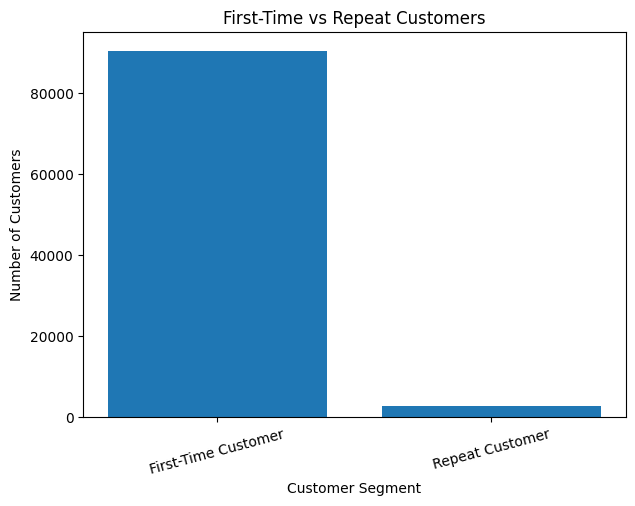

In [49]:
plt.figure(figsize=(7,5))

plt.bar(
    final_segment_table['customer_segment'],
    final_segment_table['customers']
)

plt.title('First-Time vs Repeat Customers')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.show()

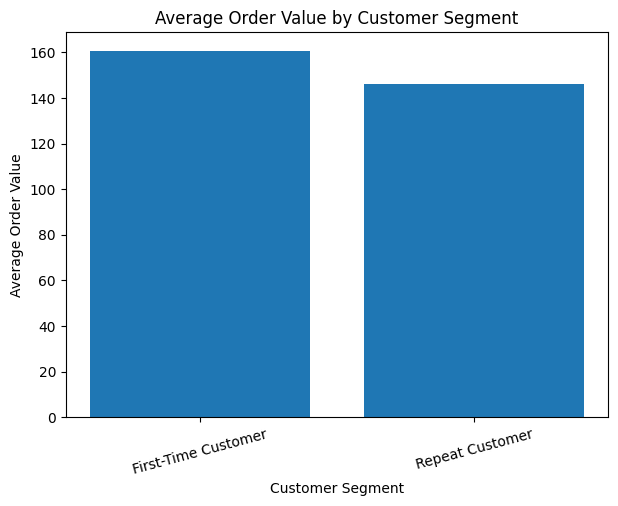

In [50]:
plt.figure(figsize=(7,5))

plt.bar(
    final_segment_table['customer_segment'],
    final_segment_table['average_order_value']
)

plt.title('Average Order Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')
plt.xticks(rotation=15)

plt.show()

In [51]:
print("CUSTOMER REPEAT PURCHASE ANALYSIS")
print("=" * 40)

print(f"Total Customers: {total_customers}")
print(f"First-Time Customers: {first_time_customers}")
print(f"Repeat Customers: {repeat_customers}")
print(f"Repeat Rate: {repeat_rate:.2f}%")
print(f"First-Time Customer AOV: {first_time_aov:.2f}")
print(f"Repeat Customer AOV: {repeat_aov:.2f}")

CUSTOMER REPEAT PURCHASE ANALYSIS
Total Customers: 93358
First-Time Customers: 90557
Repeat Customers: 2801
Repeat Rate: 3.00%
First-Time Customer AOV: 160.76
Repeat Customer AOV: 145.98


In [52]:
import sqlite3

conn = sqlite3.connect(':memory:')

customers.to_sql('customers', conn, index=False, if_exists='replace')
orders.to_sql('orders', conn, index=False, if_exists='replace')
payments.to_sql('order_payments', conn, index=False, if_exists='replace')

print("Tables created successfully!")

Tables created successfully!


In [53]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

,name
0,customers
1,orders
2,order_payments


In [54]:
sql_result = pd.read_sql("""
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS order_count
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id;
""", conn)

sql_result.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [55]:
segment_result = pd.read_sql("""
SELECT
    customer_segment,
    COUNT(*) AS customers
FROM
(
    SELECT
        c.customer_unique_id,
        CASE
            WHEN COUNT(DISTINCT o.order_id) >= 2
                THEN 'Repeat Customer'
            ELSE 'First-Time Customer'
        END AS customer_segment
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) AS customer_segments
GROUP BY customer_segment;
""", conn)

segment_result

,customer_segment,customers
0,First-Time Customer,90557
1,Repeat Customer,2801


In [56]:
repeat_rate_sql = pd.read_sql("""
SELECT
    ROUND(
        SUM(
            CASE
                WHEN order_count >= 2 THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS repeat_rate
FROM
(
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) AS customer_orders;
""", conn)

repeat_rate_sql

,repeat_rate
0,3.0


In [57]:
aov_sql = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

order_values AS (
    SELECT
        order_id,
        SUM(payment_value) AS order_value
    FROM order_payments
    GROUP BY order_id
)

SELECT
    CASE
        WHEN coc.order_count >= 2
            THEN 'Repeat Customer'
        ELSE 'First-Time Customer'
    END AS customer_segment,

    COUNT(DISTINCT c.customer_unique_id) AS customers,

    ROUND(AVG(ov.order_value), 2) AS average_order_value

FROM customers c

JOIN orders o
    ON c.customer_id = o.customer_id

JOIN customer_order_counts coc
    ON c.customer_unique_id = coc.customer_unique_id

LEFT JOIN order_values ov
    ON o.order_id = ov.order_id

WHERE o.order_status = 'delivered'

GROUP BY customer_segment;
""", conn)

aov_sql

,customer_segment,customers,average_order_value
0,First-Time Customer,90557,160.76
1,Repeat Customer,2801,145.98


In [58]:
final_sql = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

order_values AS (
    SELECT
        order_id,
        SUM(payment_value) AS order_value
    FROM order_payments
    GROUP BY order_id
),

customer_analysis AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        coc.order_count,
        ov.order_value,

        CASE
            WHEN coc.order_count >= 2
                THEN 'Repeat Customer'
            ELSE 'First-Time Customer'
        END AS customer_segment

    FROM customers c

    JOIN orders o
        ON c.customer_id = o.customer_id

    JOIN customer_order_counts coc
        ON c.customer_unique_id = coc.customer_unique_id

    LEFT JOIN order_values ov
        ON o.order_id = ov.order_id

    WHERE o.order_status = 'delivered'
)

SELECT
    customer_segment,
    COUNT(DISTINCT customer_unique_id) AS customers,
    ROUND(AVG(order_count), 2) AS average_orders,
    ROUND(AVG(order_value), 2) AS average_order_value

FROM customer_analysis

GROUP BY customer_segment;
""", conn)

final_sql

,customer_segment,customers,average_orders,average_order_value
0,First-Time Customer,90557,1.00,160.76
1,Repeat Customer,2801,2.23,145.98


In [59]:
final_sql = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

order_values AS (
    SELECT
        order_id,
        SUM(payment_value) AS order_value
    FROM order_payments
    GROUP BY order_id
),

customer_analysis AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        coc.order_count,
        ov.order_value,

        CASE
            WHEN coc.order_count >= 2
                THEN 'Repeat Customer'
            ELSE 'First-Time Customer'
        END AS customer_segment

    FROM customers c

    JOIN orders o
        ON c.customer_id = o.customer_id

    JOIN customer_order_counts coc
        ON c.customer_unique_id = coc.customer_unique_id

    LEFT JOIN order_values ov
        ON o.order_id = ov.order_id

    WHERE o.order_status = 'delivered'
)

SELECT
    customer_segment,
    COUNT(DISTINCT customer_unique_id) AS customers,
    ROUND(AVG(order_count), 2) AS average_orders,
    ROUND(AVG(order_value), 2) AS average_order_value

FROM customer_analysis

GROUP BY customer_segment;
""", conn)

final_sql

,customer_segment,customers,average_orders,average_order_value
0,First-Time Customer,90557,1.00,160.76
1,Repeat Customer,2801,2.23,145.98


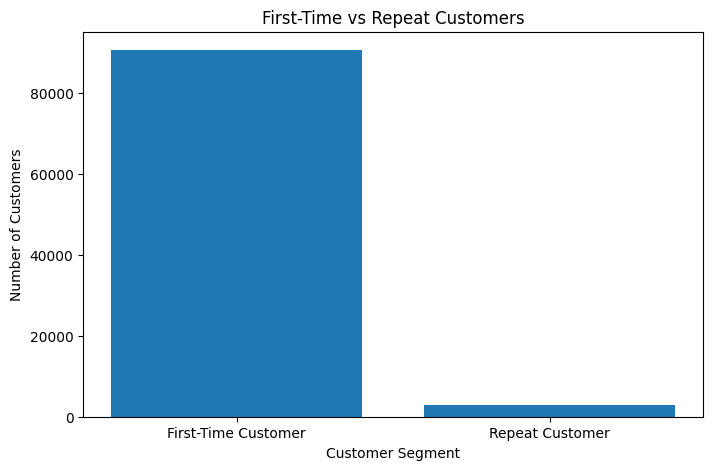

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_segment_table['customer_segment'],
    final_segment_table['customers']
)

plt.title('First-Time vs Repeat Customers')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

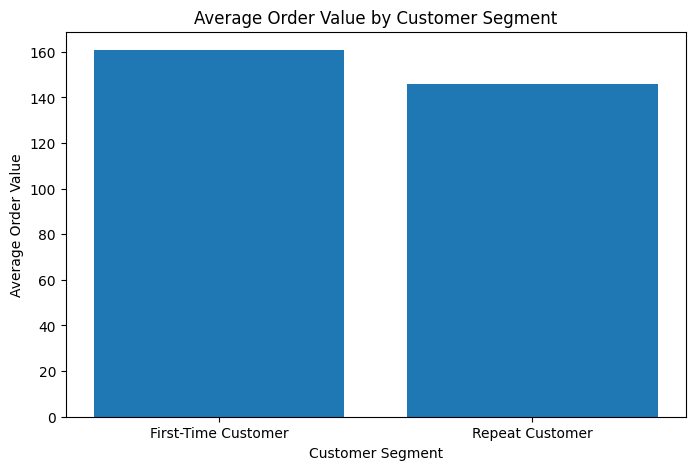

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_segment_table['customer_segment'],
    final_segment_table['average_order_value']
)

plt.title('Average Order Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')

plt.show()

In [62]:
final_results = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'First-Time Customers',
        'Repeat Customers',
        'Repeat Rate',
        'First-Time Customer AOV',
        'Repeat Customer AOV'
    ],
    'Value': [
        total_customers,
        first_time_customers,
        repeat_customers,
        f'{repeat_rate:.2f}%',
        f'{160.76:.2f}',
        f'{145.98:.2f}'
    ]
})

final_results

,Metric,Value
0,Total Customers,93358
1,First-Time Customers,90557
2,Repeat Customers,2801
3,Repeat Rate,3.00%
4,First-Time Customer AOV,160.76
5,Repeat Customer AOV,145.98


In [63]:
final_results.to_csv(
    'customer_repeat_purchase_analysis.csv',
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!
